# Multiple Linear Regression


It is an analysis to reveal the relationship between a dependent variable and a series of independent variables associated with it.

Multiple linear regression examines the linear relationship between two or more independent variables and one dependent variable. There is a correlation between dependent and independent variables in multiple regression. Let's denote the independent variables as X and the dependent variables as Y.    
                            Y=XB+E.

Y: dependent variable observation vector
X: independent variables observation matrix
B: coefficients vector
E: random error vector

SimpleLinearRegression−−>y=b0+b1x1.

MultipleLinearRegression−−>y=b0+b1x1+b2x2+⋯+bnxn.
In multiple linear regression, the degree of effect of each independent variable on the dependent variable is different from each other. Therefore, the coefficient of each variable need not be the same in addition to the equation in simple linear regression.   
![download.png](attachment:download.png)

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns;
sns.set()
import matplotlib.pyplot as plt
%matplotlib inline

# Information About Dataset


In [ ]:
df = pd.read_csv('kc_house_data.csv')
df.sample(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
3312,6638900115,20150331T000000,296000.0,2,1.00,750,4680,1.0,0,0,...,5,750.0,0,1948,0,98117,47.6919,-122.371,1450,4400
4359,2610100015,20140813T000000,305000.0,4,1.75,1000,7200,1.5,0,0,...,6,1000.0,0,1947,0,98155,47.7420,-122.324,1280,7200
10797,3223069065,20140917T000000,400000.0,2,1.75,1800,224769,1.0,0,0,...,7,1420.0,380,1950,2008,98038,47.4327,-122.060,1620,112384
1368,3905000340,20140724T000000,672000.0,4,2.50,2440,10049,2.0,0,0,...,9,2440.0,0,1989,0,98029,47.5744,-121.993,2820,8484
13499,7942600975,20140512T000000,505000.0,4,1.75,1940,4800,1.0,0,0,...,7,1030.0,910,1922,0,98122,47.6054,-122.314,1450,4800
17895,7110000068,20140703T000000,975000.0,6,2.75,2520,54160,2.0,1,4,...,7,2520.0,0,1954,0,98146,47.4969,-122.376,2790,26809
14239,4016800120,20140820T000000,374000.0,3,2.50,1850,17808,1.0,0,0,...,8,1210.0,640,1982,0,98032,47.3631,-122.271,2260,16754
16225,284000095,20140922T000000,1200000.0,2,2.25,2160,17861,2.0,1,4,...,9,2160.0,0,1956,0,98146,47.5020,-122.385,2660,18530
17678,1370801800,20140519T000000,924000.0,3,1.50,2200,5000,1.5,0,0,...,9,2200.0,0,1932,0,98199,47.6404,-122.408,2860,5000
5215,1775930010,20141222T000000,335000.0,3,2.75,1990,19991,1.0,0,0,...,7,1340.0,650,1977,0,98072,47.7434,-122.106,1750,9775


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


In [ ]:
df.drop('id', axis = 1, inplace = True)

# Data Visualization

In [ ]:
df_v = df
df_v.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [ ]:
df_v.drop(['date','zipcode', 'lat', 'long'], axis = 1, inplace = True).


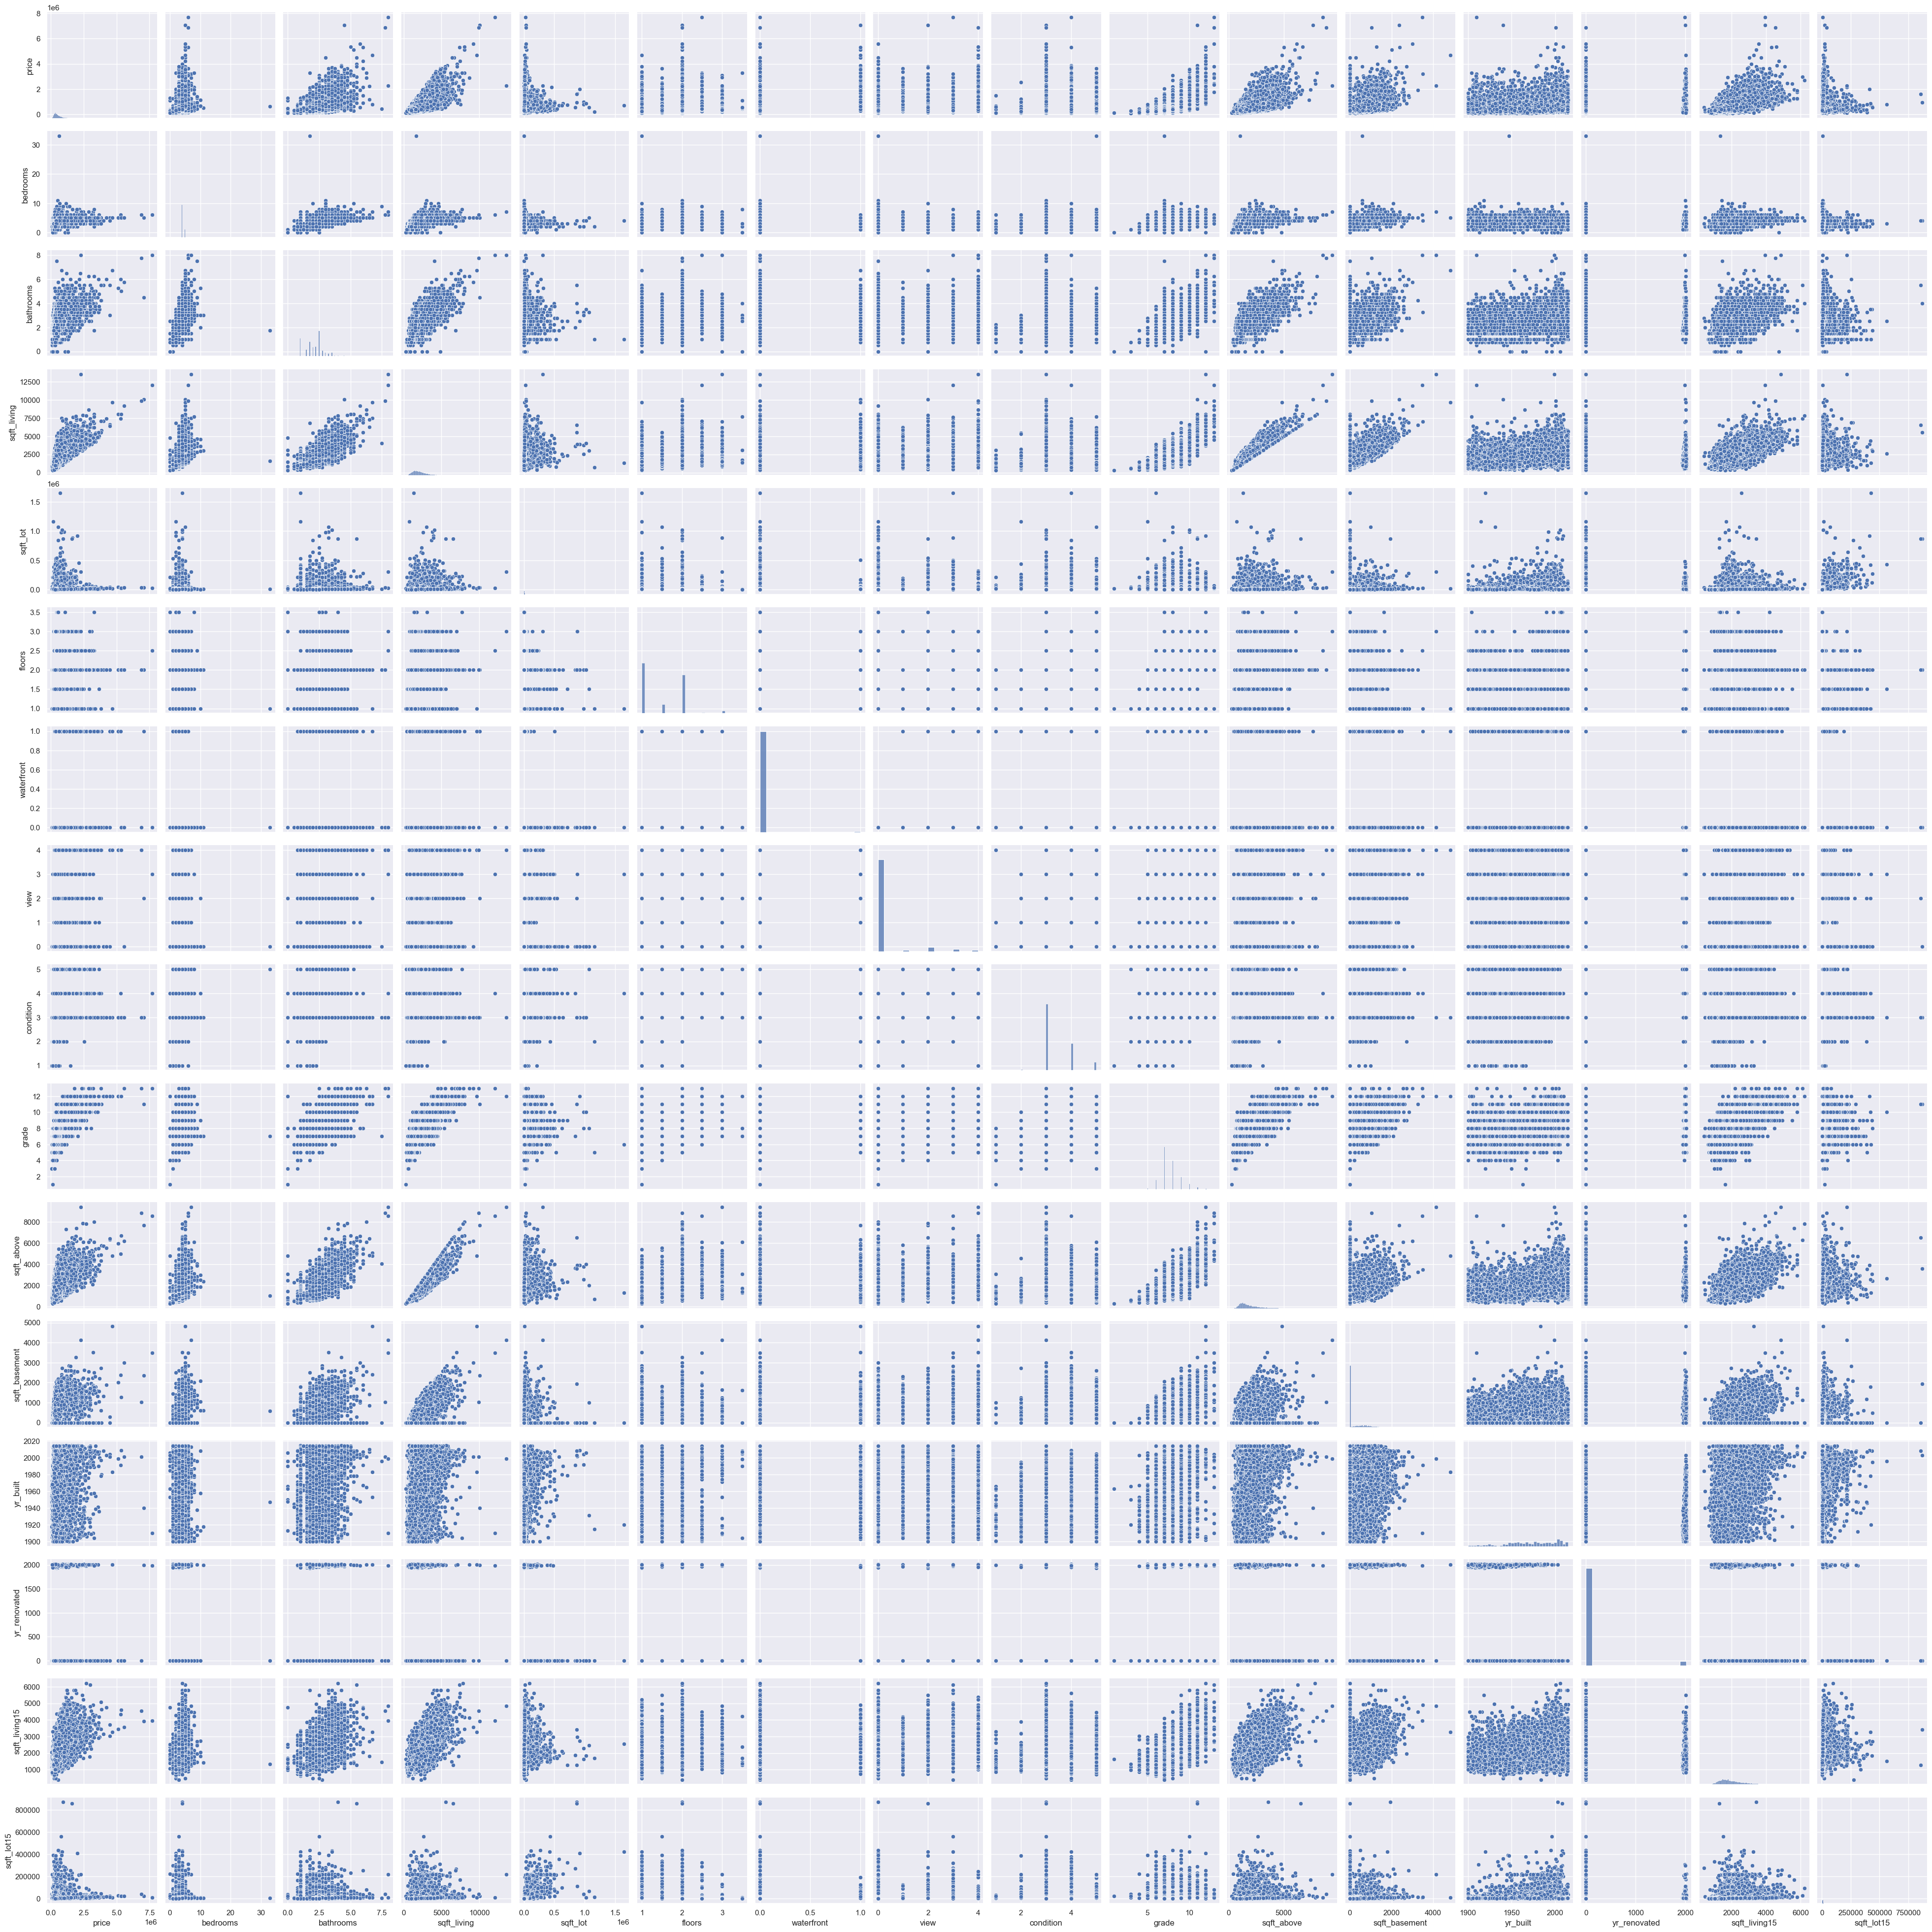

In [ ]:
sns.pairplot(data = df_v)

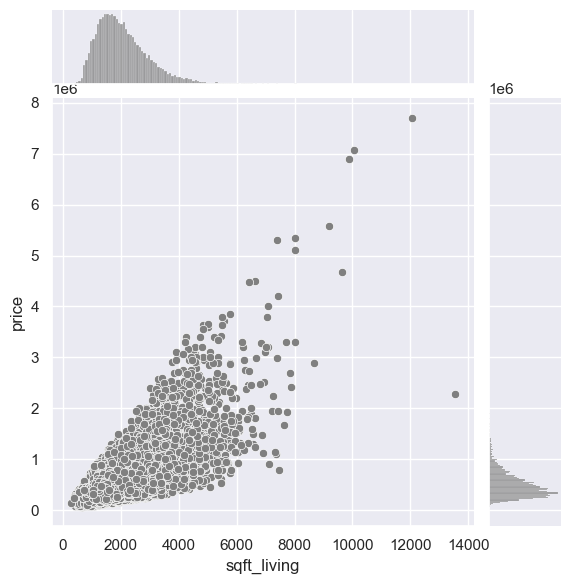

In [ ]:
sns.jointplot(x='sqft_living', y='price', data = df_v, color = 'gray')

# Correlation

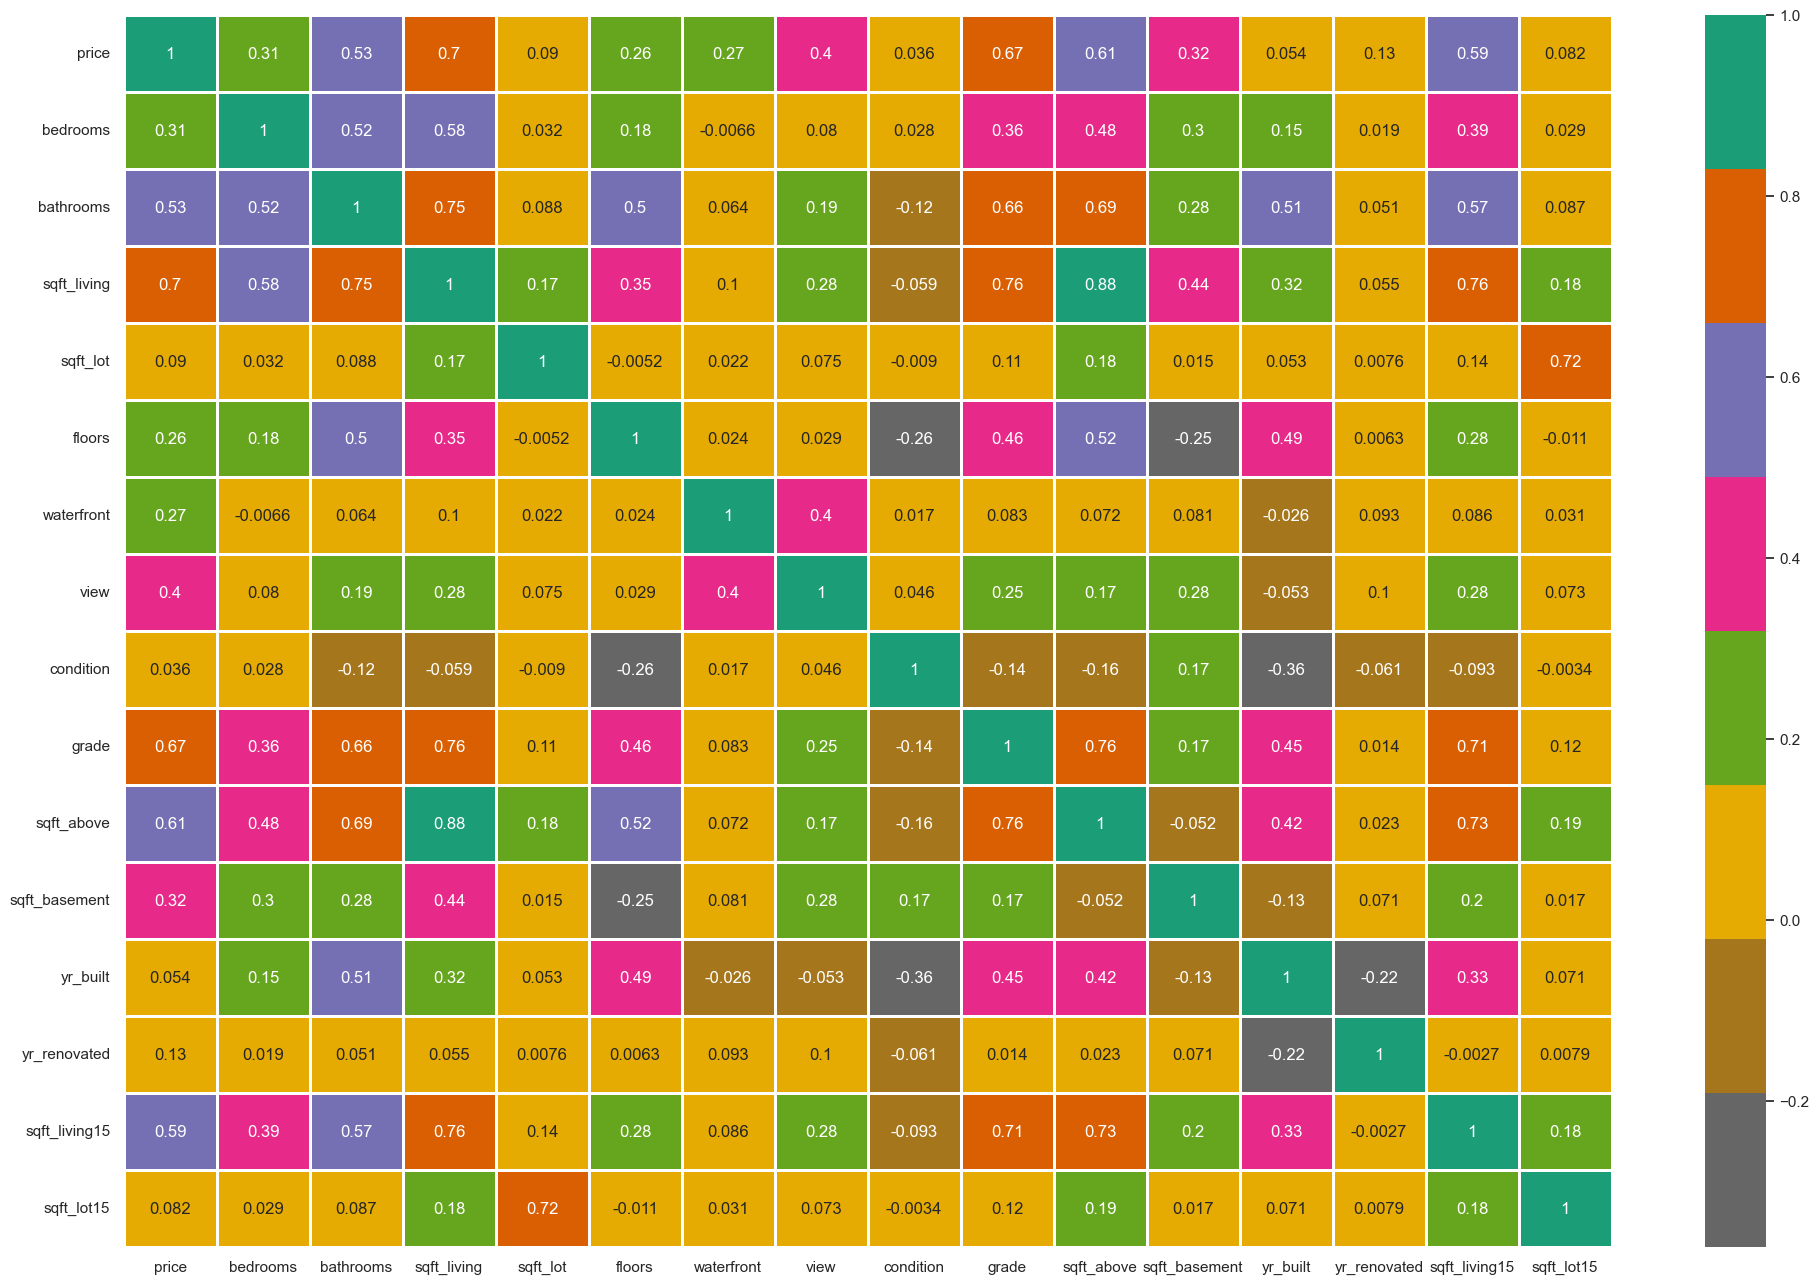

In [ ]:
plt.figure(figsize=(24,16))
sns.heatmap(df_v.corr(), annot=True, cmap='Dark2_r', linewidths = 2)
plt.show()

# Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(["price"],axis =1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 101)

print(f'Total # of sample in whole dataset: {len(X)}')
print("*****"*10)
print(f'Total # of sample in train dataset: {len(X_train)}')
print(f'Shape of X_train: {X_train.shape}')
print("*****"*10)
print(f'Total # of sample in test dataset: {len(X_test)}')
print(f'Shape of X_test: {X_test.shape}')

Total # of sample in whole dataset: 21613
**************************************************
Total # of sample in train dataset: 17290
Shape of X_train: (17290, 15)
**************************************************
Total # of sample in test dataset: 4323
Shape of X_test: (4323, 15)


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Multiple Linear Regression

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

model = make_pipeline(
    SimpleImputer(strategy='mean'),       # Fill missing values
    StandardScaler(),                     # Scale the data
    LinearRegression(fit_intercept=True)  # Fit model
)

model.fit(X_train, y_train)
pred = model.predict(X_test)


train_score = model.score(X_train, y_train)
print(f'Train score of trained model: {train_score*100}')

test_score = model.score(X_test, y_test)
print(f'Test score of trained model: {test_score*100}')

Train score of trained model: 65.07304898072975
Test score of trained model: 66.48561054799404


In [ ]:
regressor = model.named_steps['linearregression']

print('Linear Model Coefficient (m): ', regressor.coef_)
print('Linear Model Intercept (b): ', regressor.intercept_)

Linear Model Coefficient (m):  [ -34783.37447928   30953.99606626  -90718.83717846    1099.24176737
   15941.10560332   48767.85813973   32808.69813399   14363.25316458
  142092.30334036  213189.55802657  118517.92605903 -103803.14112565
    4236.37763849   17734.89225912  -15457.32641413]
Linear Model Intercept (b):  540739.7028340081


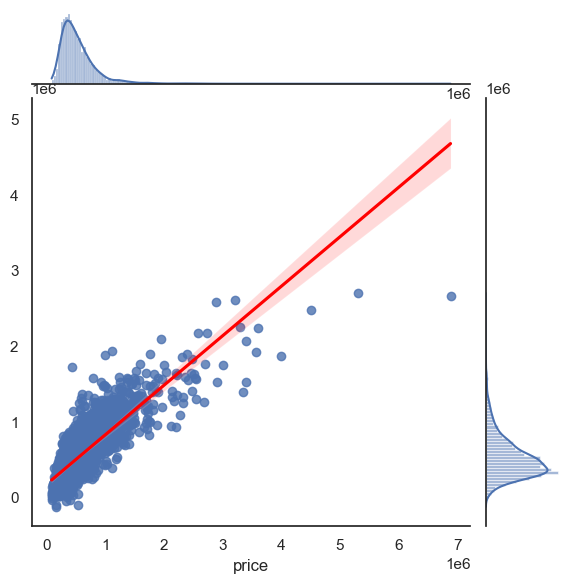

In [ ]:
sns.set_theme(style="white")
sns.jointplot(x=y_test, y=pred, kind='reg', line_kws={"color": "red"})

# Evaluation of Model

In [ ]:
import sklearn.metrics as metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from math import sqrt

k = X_test.shape[1]
n = len(X_test)

MSE = mean_squared_error(y_test, pred)
RMSE = np.sqrt(metrics.mean_squared_error(y_test, pred))
MAE = mean_absolute_error(y_test, pred)
MAPE = np.mean(np.abs( (y_test-pred) / y_test))*100
r2 = r2_score(y_test, pred)
adj_r2 = 1-(1-r2) * (n-1)/(n-k-1)

results = [MSE, RMSE, MAE, MAPE, r2, adj_r2]
metrics = ['MSE', 'RMSE', 'MAE', 'MAPE', 'r2', 'adj_r2']

table_results = pd.DataFrame({'Metric': metrics, 'Score': results})
table_results

,Metric,Score
0,MSE,4.572417e+10
1,RMSE,2.138321e+05
2,MAE,1.363323e+05
3,MAPE,2.878342e+01
4,r2,6.648561e-01
5,adj_r2,6.636889e-01


# Information About Dataset

In [ ]:
df = pd.read_csv('HouseSalesPrediction _kc_house_data.csv')
df.sample(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
19866,8024200677,20150429T000000,415000.0,3,1.50,1270,1483,3.0,0,0,...,8,1270,0,2007,0,98115,47.6987,-122.317,1270,1413
9950,3438502200,20140917T000000,445000.0,4,2.75,2680,16934,1.0,0,0,...,7,1340,1340,1958,0,98106,47.5420,-122.364,1240,7000
9650,8835200790,20150406T000000,280000.0,2,1.00,870,4025,1.0,0,0,...,7,870,0,1981,0,98034,47.7243,-122.161,1370,3488
12326,8001470560,20141117T000000,925900.0,4,3.75,3980,7828,2.0,0,0,...,10,3980,0,2001,0,98074,47.6303,-122.065,3980,8910
13469,871001085,20150129T000000,652000.0,3,1.00,1470,6122,1.0,0,0,...,8,1200,270,1948,0,98199,47.6517,-122.406,2200,6122
8562,9376301520,20140529T000000,595000.0,3,2.00,1480,5000,1.0,0,0,...,7,750,730,1928,0,98117,47.6859,-122.370,1250,4000
21333,2424059174,20150508T000000,1999950.0,4,3.25,5640,35006,2.0,0,2,...,11,4900,740,2015,0,98006,47.5491,-122.104,4920,35033
15068,7202330920,20140807T000000,464000.0,3,2.50,1690,4898,2.0,0,0,...,7,1690,0,2003,0,98053,47.6834,-122.038,2220,4933
13510,8945100530,20150313T000000,172380.0,3,1.00,970,8378,1.0,0,0,...,6,970,0,1962,0,98023,47.3078,-122.365,1050,8563
8764,8562720410,20140807T000000,1200000.0,5,3.25,4610,10576,2.0,0,3,...,11,3310,1300,2006,0,98027,47.5373,-122.070,4042,8321


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [ ]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
df.drop('id', axis = 1, inplace = True)
df.drop('date', axis = 1, inplace = True)
df.drop('zipcode', axis = 1, inplace = True)
df.drop('lat', axis = 1, inplace = True)
df.drop('long', axis = 1, inplace = True)

# Data Visualization

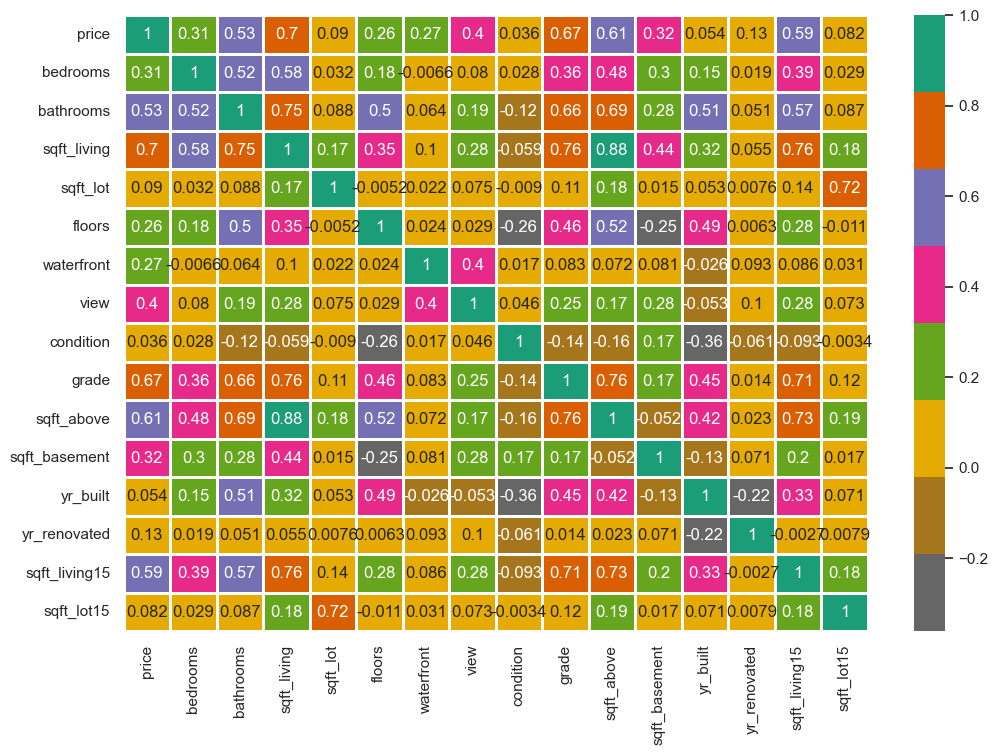

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='Dark2_r', linewidths = 2)
plt.show()

# Train-Test Split

In [ ]:
columns = df.columns.drop('price')

features = columns
label = ['price']

X = df[features]
y = df[label]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 101)

print(f'Total # of sample in whole dataset: {len(X)}')
print("*****"*10)
print(f'Total # of sample in train dataset: {len(X_train)}')
print(f'Shape of X_train: {X_train.shape}')
print("*****"*10)
print(f'Total # of sample in test dataset: {len(X_test)}')
print(f'Shape of X_test: {X_test.shape}')

Total # of sample in whole dataset: 21613
**************************************************
Total # of sample in train dataset: 19451
Shape of X_train: (19451, 15)
**************************************************
Total # of sample in test dataset: 2162
Shape of X_test: (2162, 15)


# Ridge Regression (L2 Regularization)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline that first normalizes the data, then applies Ridge
ridge = make_pipeline(StandardScaler(), Ridge(alpha=0.001))

ridge.fit(X_train, y_train)

pred = ridge.predict(X_test)

train_score = ridge.score(X_train, y_train)
print(f'Train score of trained model: {train_score * 100:.2f}')

test_score = ridge.score(X_test, y_test)
print(f'Test score of trained model: {test_score * 100:.2f}')


Train score of trained model: 65.29
Test score of trained model: 65.80


In [ ]:
k = X_test.shape[1]
n = len(X_test)

MSE = mean_squared_error(y_test, pred)
RMSE = np.sqrt(mean_squared_error(y_test, pred))
MAE = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
adj_r2 = 1-(1-r2) * (n-1)/(n-k-1)

results = [MSE, RMSE, MAE, r2, adj_r2]
metrics = ['MSE', 'RMSE', 'MAE', 'r2', 'adj_r2']

table_results = pd.DataFrame({'Metric': metrics, 'Score': results})
table_results

,Metric,Score
0,MSE,5.388590e+10
1,RMSE,2.321334e+05
2,MAE,1.374801e+05
3,r2,6.579723e-01
4,adj_r2,6.555816e-01


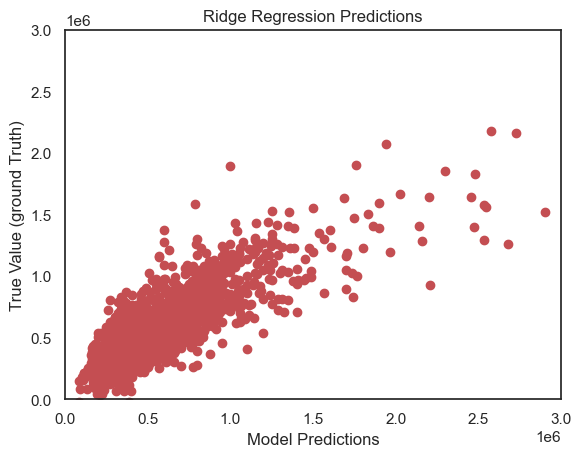

In [ ]:
plt.plot(y_test, pred, "o", color = 'r')
plt.xlim(0, 3000000)
plt.ylim(0, 3000000)

plt.xlabel("Model Predictions")
plt.ylabel("True Value (ground Truth)")
plt.title('Ridge Regression Predictions')
plt.show()

# Lasso Regression (L1 Regularization)

It performs both variable selection and regularization in order to increase the prediction accuracy and interpretability of the model it produces.
Just like in ridge regression, the aim is to find the coefficients that minimize the sum of squares error by applying penalties to the coefficients. But unlike ridge regression, it sets the coefficients of irrelevant variables equal to zero.

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline that scales and then applies Lasso
lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.001))

lasso.fit(X_train, y_train)

pred = lasso.predict(X_test)

train_score = lasso.score(X_train, y_train)
print(f'Train score of trained model: {train_score * 100:.2f}')

test_score = lasso.score(X_test, y_test)
print(f'Test score of trained model: {test_score * 100:.2f}')


Train score of trained model: 65.29
Test score of trained model: 65.80


C:\Users\rohit\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.767e+13, tolerance: 2.572e+11
  model = cd_fast.enet_coordinate_descent(


In [ ]:
k = X_test.shape[1]
n = len(X_test)

MSE = mean_squared_error(y_test, pred)
RMSE = np.sqrt(mean_squared_error(y_test, pred))
MAE = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
adj_r2 = 1-(1-r2) * (n-1)/(n-k-1)

results = [MSE, RMSE, MAE, r2, adj_r2]
metrics = ['MSE', 'RMSE', 'MAE', 'r2', 'adj_r2']

table_results = pd.DataFrame({'Metric': metrics, 'Score': results})
table_results

,Metric,Score
0,MSE,5.388590e+10
1,RMSE,2.321334e+05
2,MAE,1.374801e+05
3,r2,6.579723e-01
4,adj_r2,6.555816e-01


# Elastic Net


The goal is the same as ridge and lasso regression, but elastic net combines ridge and lasso regression. Ridge regression style penalization and lasso regression style variable selection.

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Pipeline with normalization followed by ElasticNet
e_net = make_pipeline(StandardScaler(), ElasticNet(alpha=0.1, l1_ratio=0.5))

e_net.fit(X_train, y_train)

pred = e_net.predict(X_test)

train_score = e_net.score(X_train, y_train)
print(f'Train score of trained model: {train_score * 100:.2f}')

test_score = e_net.score(X_test, y_test)
print(f'Test score of trained model: {test_score * 100:.2f}')


Train score of trained model: 65.17
Test score of trained model: 65.40


In [ ]:
k = X_test.shape[1]
n = len(X_test)

MSE = mean_squared_error(y_test, pred)
RMSE = np.sqrt(mean_squared_error(y_test, pred))
MAE = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
adj_r2 = 1-(1-r2) * (n-1)/(n-k-1)

results = [MSE, RMSE, MAE, r2, adj_r2]
metrics = ['MSE', 'RMSE', 'MAE', 'r2', 'adj_r2']

table_results = pd.DataFrame({'Metric': metrics, 'Score': results})
table_results

,Metric,Score
0,MSE,5.450728e+10
1,RMSE,2.334679e+05
2,MAE,1.366960e+05
3,r2,6.540283e-01
4,adj_r2,6.516100e-01


# Conclusion

We have come to the end of the notebook. I covered basic regression techniques and problems in this notebook. I hope you liked it.

